## 1. Environment Setup & Data Loading

### 1. Import Libraries
Import all necessary Python libraries for data manipulation, visualization, preprocessing, model training, evaluation, and saving.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 2. Load Dataset
Read the dataset from the data directory and display the first 5 rows to inspect the structure.

In [3]:
df = pd.read_csv('data/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2. Data Cleaning & Inspection

### 1. Data Structure, Missing Values, and Duplicates Inspection
Check data types, non-null counts, memory usage, and inspect for any duplicate records in the dataset.

In [4]:
df.info()
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64



### 2. Remove Duplicate Rows and Summary Statistics
Remove duplicate records from the dataset to prevent data leakage and display summary statistics for all numerical features.

In [5]:
df = df.drop_duplicates().reset_index(drop=True)
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 3. Exploratory Data Analysis (EDA)

### 1. Target Variable Distribution Analysis
Analyze the distribution of the target variable to check for class balance between individuals with and without heart disease.

C:\Users\M lapan\AppData\Local\Temp\ipykernel_11608\827000516.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[1].set_xticklabels(['No Disease', 'Disease'])


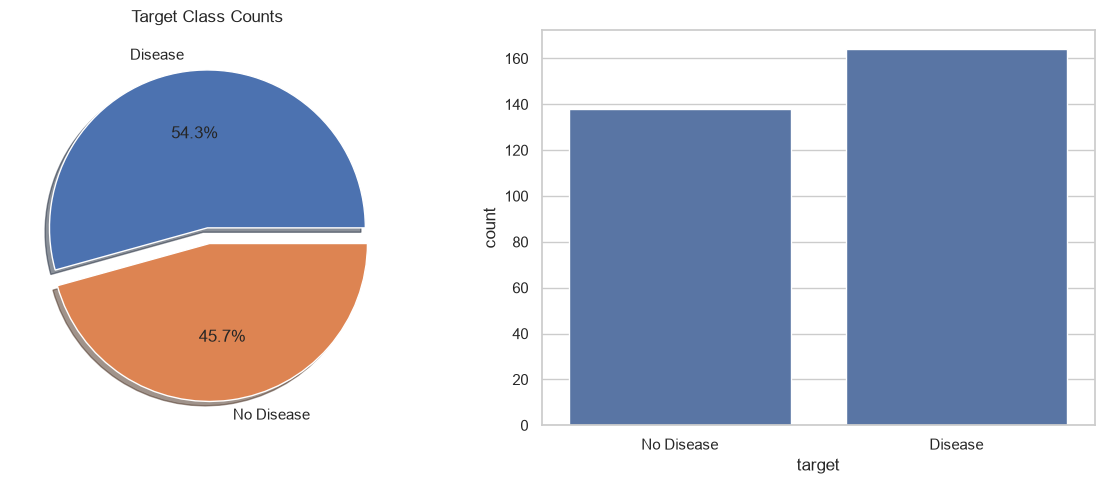

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

df['target'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    ax=ax[0], 
    shadow=True, 
    explode=[0, 0.1], 
    labels=['Disease', 'No Disease']
)
ax[0].set_title('Target Class Distribution (%)')
ax[0].set_ylabel('')

sns.countplot(x='target', data=df, ax=ax[1])
ax[0].set_title('Target Class Counts')
ax[1].set_xticklabels(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

### 2. Numerical Features Distribution
Visualize the distributions of key continuous numerical features (age, resting blood pressure, cholesterol, and maximum heart rate) to inspect their scale and detect potential outliers.

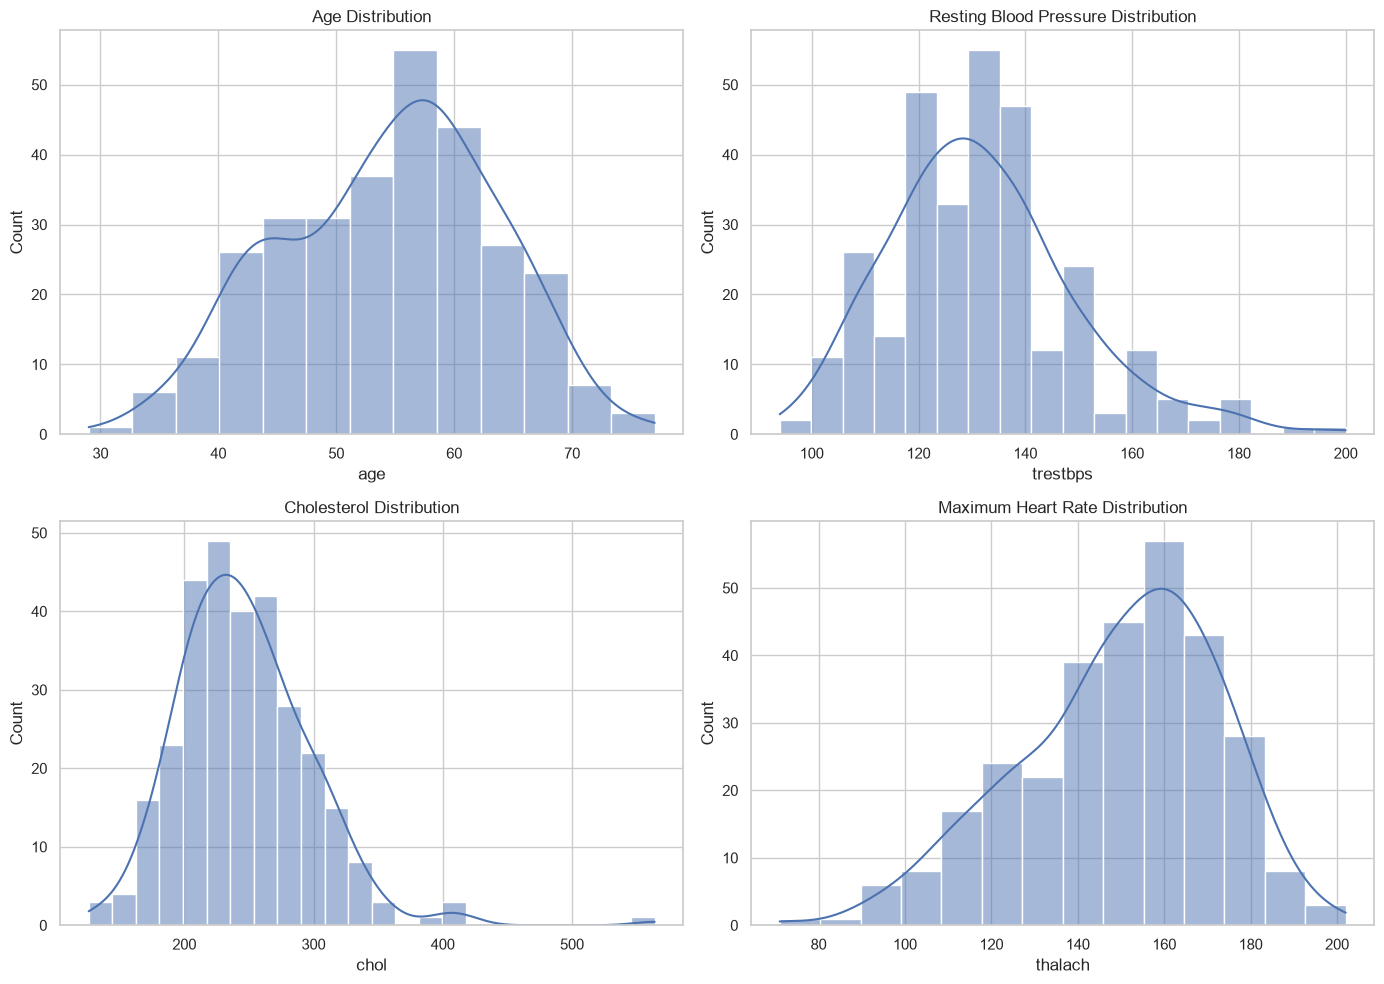

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['age'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution')

sns.histplot(df['trestbps'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Resting Blood Pressure Distribution')

sns.histplot(df['chol'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Cholesterol Distribution')

sns.histplot(df['thalach'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Maximum Heart Rate Distribution')

plt.tight_layout()
plt.show()

### 3. Categorical Features vs Target Analysis
Analyze the relationship between key categorical features (Sex and Chest Pain Type) and heart disease prevalence.

C:\Users\M lapan\AppData\Local\Temp\ipykernel_11608\2165648386.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Female', 'Male'])


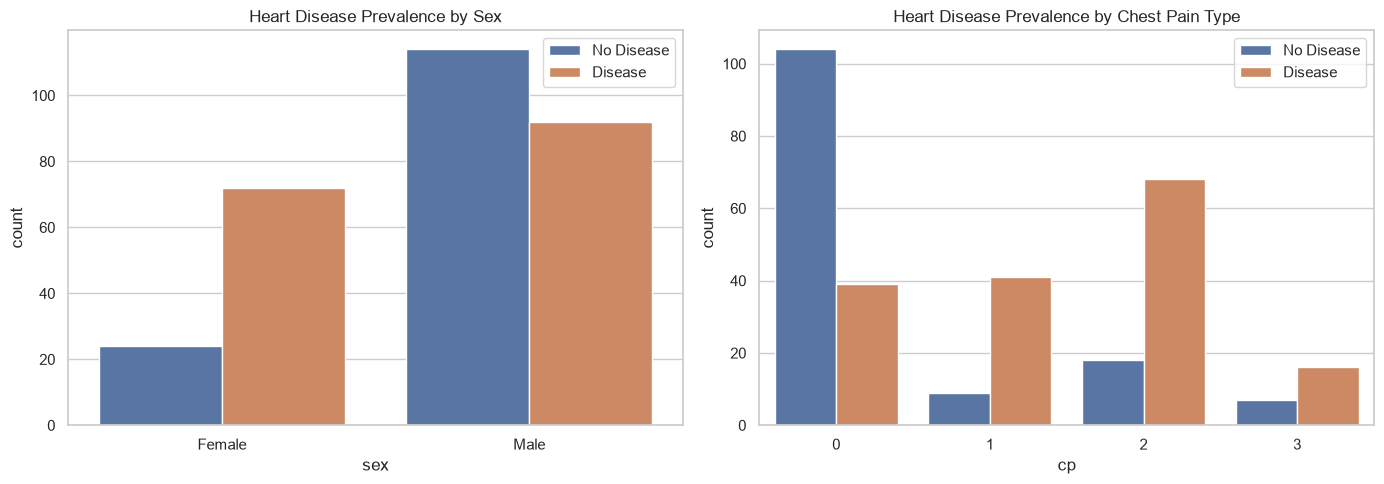

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='sex', hue='target', data=df, ax=axes[0])
axes[0].set_title('Heart Disease Prevalence by Sex')
axes[0].set_xticklabels(['Female', 'Male'])
axes[0].legend(['No Disease', 'Disease'])

sns.countplot(x='cp', hue='target', data=df, ax=axes[1])
axes[1].set_title('Heart Disease Prevalence by Chest Pain Type')
axes[1].legend(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

### 4. Correlation Matrix Heatmap
Compute and visualize the correlation matrix to identify relationships between features and their linear correlation with the target variable.

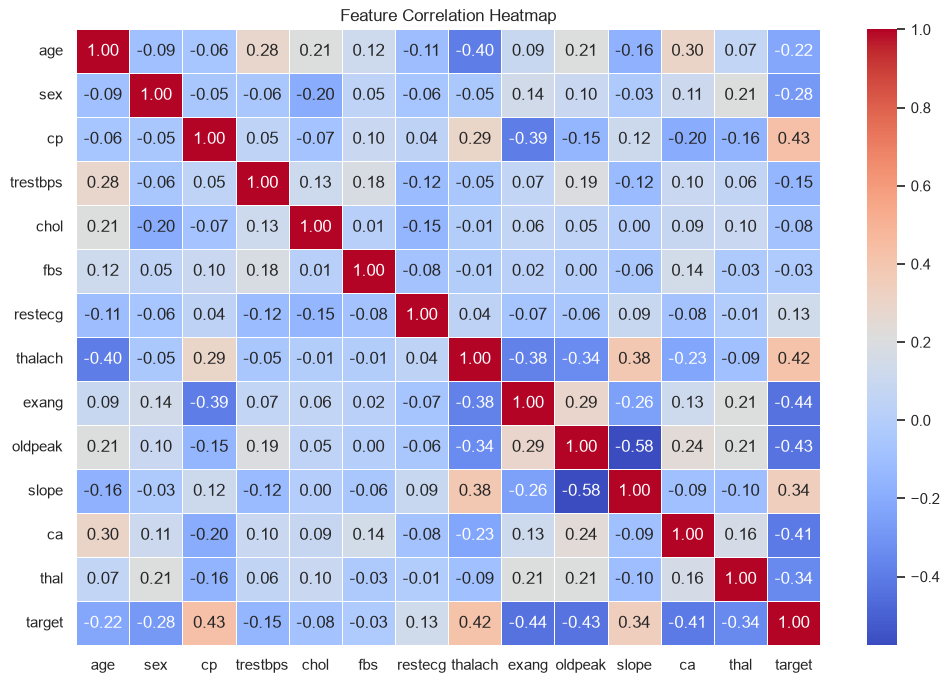

In [9]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

## 4. Data Preprocessing

### 1- Feature Splitting & Train-Test Split
Separate the independent feature matrix from the target label and divide the dataset into 80% training and 20% testing sets using stratified sampling to maintain class ratios.

In [10]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (241, 13)
X_test shape: (61, 13)


### 2- Feature Scaling
Apply StandardScaler to normalize continuous numerical features, ensuring all input variables share a zero mean and unit variance.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaled X_train shape: (241, 13)
Scaled X_test shape: (61, 13)


## 5. Model Training & Evaluation

### 1- Logistic Regression Model Training & Evaluation
Train a Logistic Regression classifier on the scaled training data, make predictions on the test set, and evaluate performance using Accuracy Score, Confusion Matrix, and Classification Report.

In [12]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy * 100:.2f}%\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 80.33%

Confusion Matrix:
[[21  7]
 [ 5 28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



### 2- Model & Scaler Serialization
Save the trained Logistic Regression model and the fitted StandardScaler instance to disk using joblib for downstream deployment in Streamlit.

In [13]:
import os

os.makedirs('models', exist_ok=True)

joblib.dump(model, 'models/heart_disease_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("Model and Scaler successfully saved to the 'models/' directory.")

Model and Scaler successfully saved to the 'models/' directory.
